In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        break
    break

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import os

In [3]:
import matplotlib.pyplot as plt
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


## Download train, validation and test dataframes

In [4]:
train_id = "16ADiN0-geWlmkhN04bymFy_N7OA0SPHy"
train_url = f'https://drive.google.com/uc?id={train_id}'
# Load the CSV file into a pandas DataFrame
train_df = pd.read_csv(train_url)
train_df.head()

,File,Encoded_Label
0,n02437312/images/n02437312_229.JPEG,53
1,n02437312/images/n02437312_394.JPEG,53
2,n02437312/images/n02437312_15.JPEG,53
3,n02437312/images/n02437312_62.JPEG,53
4,n02437312/images/n02437312_17.JPEG,53


In [5]:
train_df["Encoded_Label"]

0         53
1         53
2         53
3         53
4         53
        ... 
99995    121
99996    121
99997    121
99998    121
99999    121
Name: Encoded_Label, Length: 100000, dtype: int64

In [6]:
val_id = "1lGkKcAD6Kc7JhfYsa9naVIwwc-MKdXQI"
val_url = f'https://drive.google.com/uc?id={val_id}'
# Load the CSV file into a pandas DataFrame
val_df = pd.read_csv(val_url)
val_df.head()

,File,Encoded_Label
0,val_4526.JPEG,115
1,val_7545.JPEG,88
2,val_1726.JPEG,149
3,val_4997.JPEG,99
4,val_6429.JPEG,149


In [7]:
test_id = "1lOi6xnfVghuzj1fYlIBbLNWWZQvahygQ"
test_url = f'https://drive.google.com/uc?id={test_id}'
# Load the CSV file into a pandas DataFrame
test_df = pd.read_csv(test_url)
test_df.head()

,File
0,val_9240.JPEG
1,val_9308.JPEG
2,val_3262.JPEG
3,val_3528.JPEG
4,val_4147.JPEG


In [10]:
class CSVImageDataset(Dataset):
    def __init__(self, df, images_dir, transform=None):
        self.df = df
        self.images_dir = images_dir
        self.transform = transform
        self.has_labels = "Encoded_Label" in self.df.columns

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row["File"])
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        if self.has_labels:
            return img, torch.tensor(row["Encoded_Label"], dtype=torch.long)
        return img


In [11]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.12), ratio=(0.3, 3.3)),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])


# ── Datasets ──────────────────────────────────────────────────────────────────
TRAIN_DIR = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train/"
VAL_DIR = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/val/images/"

train_dataset = CSVImageDataset(train_df, TRAIN_DIR, transform=train_transform)
val_dataset   = CSVImageDataset(val_df,   VAL_DIR, transform=test_transform)
test_dataset  = CSVImageDataset(test_df,  VAL_DIR, transform=test_transform)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

# ── Sanity check ──────────────────────────────────────────────────────────────
images, labels = next(iter(train_loader))
print(f"Batch shape : {images.shape}")   # [64, 3, 128, 128]
print(f"Labels shape: {labels.shape}")   # [64]
print(f"Unique labels in batch: {labels.unique()}")

Batch shape : torch.Size([64, 3, 224, 224])
Labels shape: torch.Size([64])
Unique labels in batch: tensor([  7,  10,  16,  17,  21,  25,  27,  28,  29,  33,  38,  41,  48,  53,
         55,  60,  64,  66,  68,  72,  73,  78,  79,  87,  89,  91,  93,  94,
         96,  99, 101, 102, 104, 107, 123, 130, 131, 133, 134, 144, 147, 156,
        157, 166, 169, 170, 172, 177, 182, 183, 185, 186, 190, 191, 198, 199])


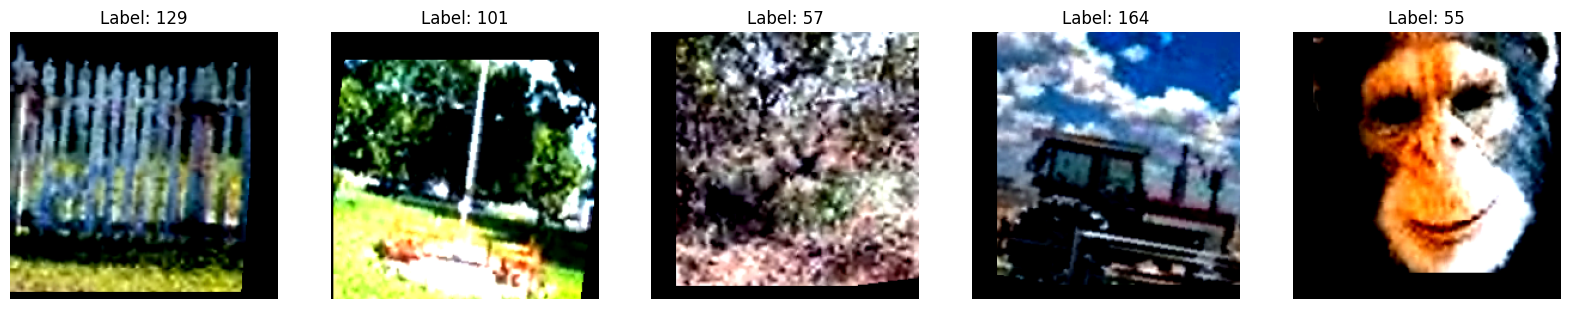

In [12]:
# Plotting the first few images in the batch
images, labels = next(iter(train_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {int(labels[i])}")
plt.show()

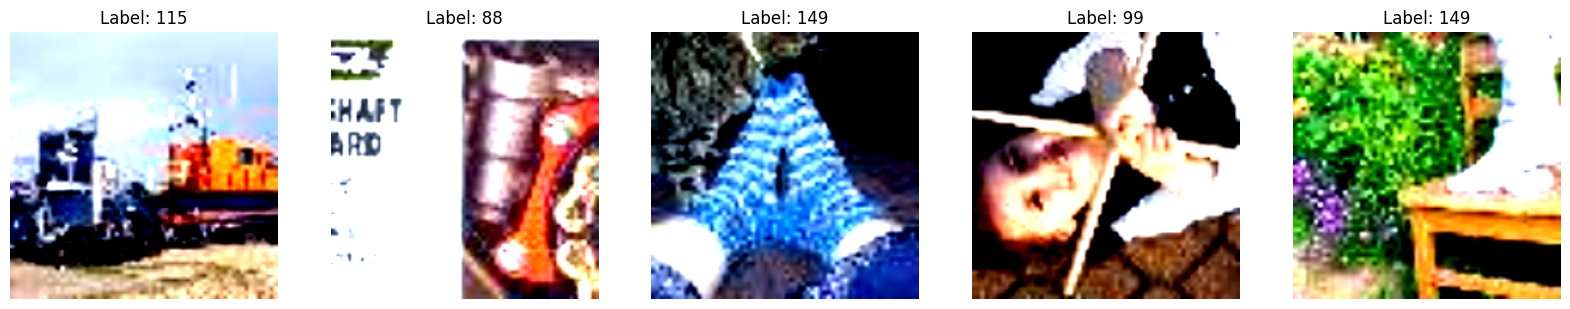

In [13]:
# Plotting the first few images in the batch
images, labels = next(iter(val_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {int(labels[i])}")
plt.show()

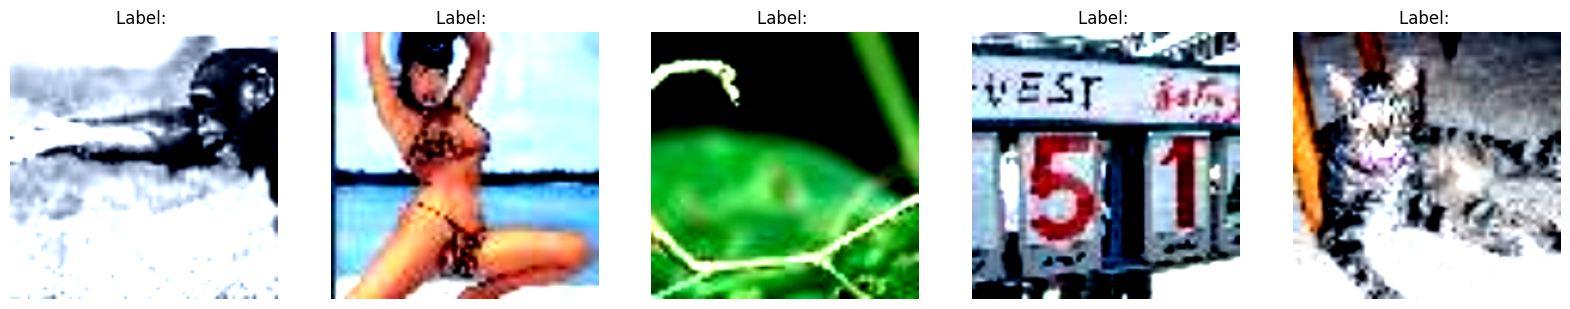

In [14]:
# Plotting the first few images in the batch
images = next(iter(test_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: ")
plt.show()

## Test Set — No Labels Available

 The test set does not include ground-truth labels. To evaluate your model
 on the test set, you need to:

 1. Run inference on the test loader to get predictions for each image
 2. Create a CSV with two columns: `File` (the image filename) and `Encoded_Label` (your predicted class)
 3. Submit that CSV for evaluation

 You can generate it like this:

 ```python
 import torch
 import pandas as pd

 model.eval()
 filenames   = test_dataset.df["File"].tolist()
 predictions = []

 with torch.inference_mode():
     for i, images in enumerate(test_loader):
         images  = images.to(device)
         logits  = model(images)
         preds   = logits.argmax(dim=1).cpu().tolist()
         predictions.extend(preds)

 submission = pd.DataFrame({"File": filenames, "Encoded_Label": predictions})
 submission.to_csv("submission.csv", index=False)
 print(submission.head())
 ```

 Make sure the order of `filenames` matches the order images are loaded
 by the test loader — since `shuffle=False`, the order is preserved.

In [15]:
import torch
import torch.nn as nn
from torchvision import models

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── Modelo ────────────────────────────────────────────────────────────────────
model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 200)
)

model = model.to(device)

# ── Resumen básico ────────────────────────────────────────────────────────────
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\nTotal params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")
print(f"Output classes   : 200")

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 191MB/s] 


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [17]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import torchmetrics

# ── Loss, optimizer, scheduler ────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

# ── Funciones ─────────────────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    metric = torchmetrics.Accuracy(task="multiclass", num_classes=200).to(device)
    metric.reset()

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        metric.update(outputs, labels)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = metric.compute().item()

    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    metric = torchmetrics.Accuracy(task="multiclass", num_classes=200).to(device)
    metric.reset()

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        metric.update(outputs, labels)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = metric.compute().item()

    return epoch_loss, epoch_acc

# ── Entrenamiento ─────────────────────────────────────────────────────────────
MAX_EPOCHS = 10

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_acc)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, "best_resnet34_tinyimagenet.pth")

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"LR: {current_lr:.6f} | "
        f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}"
    )

# ── Cargar mejor modelo al final ──────────────────────────────────────────────
model.load_state_dict(best_model_wts)
print(f"\nMejor accuracy de validación: {best_val_acc:.4f}")

Epoch 01/10 | LR: 0.000100 | Train Loss: 2.9774  Acc: 0.4514 | Val Loss: 2.1269  Acc: 0.6457
Epoch 02/10 | LR: 0.000100 | Train Loss: 2.2314  Acc: 0.6204 | Val Loss: 2.0017  Acc: 0.6842
Epoch 03/10 | LR: 0.000100 | Train Loss: 2.0508  Acc: 0.6686 | Val Loss: 1.9660  Acc: 0.6982
Epoch 04/10 | LR: 0.000100 | Train Loss: 1.9293  Acc: 0.7043 | Val Loss: 1.9539  Acc: 0.7073
Epoch 05/10 | LR: 0.000100 | Train Loss: 1.8405  Acc: 0.7290 | Val Loss: 1.9188  Acc: 0.7072
Epoch 06/10 | LR: 0.000100 | Train Loss: 1.7681  Acc: 0.7483 | Val Loss: 1.9097  Acc: 0.7138
Epoch 07/10 | LR: 0.000100 | Train Loss: 1.7047  Acc: 0.7662 | Val Loss: 1.9101  Acc: 0.7140
Epoch 08/10 | LR: 0.000100 | Train Loss: 1.6486  Acc: 0.7825 | Val Loss: 1.9077  Acc: 0.7113
Epoch 09/10 | LR: 0.000100 | Train Loss: 1.5924  Acc: 0.8012 | Val Loss: 1.9307  Acc: 0.7145
Epoch 10/10 | LR: 0.000100 | Train Loss: 1.5499  Acc: 0.8119 | Val Loss: 1.9090  Acc: 0.7208

Mejor accuracy de validación: 0.7208


---
## Análisis y reflexión

**1. ¿Qué accuracy obtuviste en validación?**  
Mejor accuracy de validación: **72.08%** (época 10). Train accuracy final: **81.19%**.

**2. ¿Por qué usar ResNet34 preentrenado?**  
Transfer learning desde ImageNet aporta filtros convolucionales ya útiles para texturas y formas. Solo se reentrena la cabeza (`fc`) para **200 clases** de Tiny ImageNet, reduciendo tiempo de convergencia frente a entrenar desde cero.

**3. ¿Qué aporta la augmentación?**  
Flip, rotación, `ColorJitter`, `RandomResizedCrop`, `RandomAffine` y `RandomErasing` aumentan variabilidad en train y ayudan a **generalizar** en un dataset con imágenes 64×64 ampliadas a 224×224.

**4. ¿Hay sobreajuste?**  
Sí, leve. La brecha train–val (~81% vs ~72%) indica que el modelo memoriza parte del entrenamiento. `Dropout(0.3)`, `weight_decay` y `label_smoothing=0.1` mitigan pero no eliminan el gap.

**5. Hiperparámetros clave**  
- `CrossEntropyLoss` con label smoothing 0.1  
- `AdamW`, lr=1e-4, weight_decay=1e-4  
- `ReduceLROnPlateau` (patience=2, factor=0.5)  
- Batch size 64, 10 épocas, checkpoint del mejor modelo en val  

**6. Entrega test**  
El test no tiene labels. Generar `submission.csv` con columnas `File` y `Encoded_Label` usando inferencia sobre `test_loader` (shuffle=False).
